
Cr_R1s(r) =
+230.4727 * exp(-24.7292 r)
+163.4929 * r * exp(-21.1386 r)
+0.3134 * r * exp(-9.9971 r)
+598.6109 * r^2 * exp(-30.4212 r)
+0.0087 * r^2 * exp(-7.3629 r)
-0.0168 * r^2 * exp(-5.1830 r)
+0.0008 * r^2 * exp(-3.4391 r)
-0.5330 * r^3 * exp(-11.9538 r)
-0.0000 * r^3 * exp(-2.1124 r)
+0.0000 * r^3 * exp(-1.3241 r)
-0.0000 * r^3 * exp(-0.8703 r)

Cr_R2s(r) =
+69.0886 * exp(-24.7292 r)
+421.2281 * r * exp(-21.1386 r)
-372.9086 * r * exp(-9.9971 r)
+65.5375 * r^2 * exp(-30.4212 r)
-38.2975 * r^2 * exp(-7.3629 r)
+1.0616 * r^2 * exp(-5.1830 r)
-0.0972 * r^2 * exp(-3.4391 r)
-543.9216 * r^3 * exp(-11.9538 r)
+0.0011 * r^3 * exp(-2.1124 r)
-0.0001 * r^3 * exp(-1.3241 r)
+0.0000 * r^3 * exp(-0.8703 r)

Cr_R3s(r) =
-25.0101 * exp(-24.7292 r)
-176.1227 * r * exp(-21.1386 r)
+159.1316 * r * exp(-9.9971 r)
-67.8945 * r^2 * exp(-30.4212 r)
+49.5578 * r^2 * exp(-7.3629 r)
-84.5034 * r^2 * exp(-5.1830 r)
-18.5583 * r^2 * exp(-3.4391 r)
+717.9020 * r^3 * exp(-11.9538 r)
-0.0361 * r^3 * exp(-2.

/tmp/ipykernel_10425/3243563613.py:129: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


Norm 1s = 0.9994408437647027
Norm 2s = 0.9999465595367403
Norm 2p = 0.9999999259372596
Norm 3s = 0.9999926725964836
Norm 3p = 1.0000007600028493
Norm 3d = 1.0000002584290835
Norm 4s = 0.9999982834256398
           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00           0.036476       1.398260e-01       3.988823e-01   
1       0.05           0.036476       1.397978e-01       3.981769e-01   
2       0.10           0.036474       1.397132e-01       3.960694e-01   
3       0.15           0.036472       1.395725e-01       3.925853e-01   
4       0.20           0.036468       1.393760e-01       3.877660e-01   
...      ...                ...                ...                ...   
1996   99.80           0.000004       3.501157e-07       4.630912e-08   
1997   99.85           0.000004       3.485748e-07       4.610505e-08   
1998   99.90           0.000004       3.470391e-07       4.590166e-08   
1999   99.95           0.000004       3.455085e-07       4.569896e-

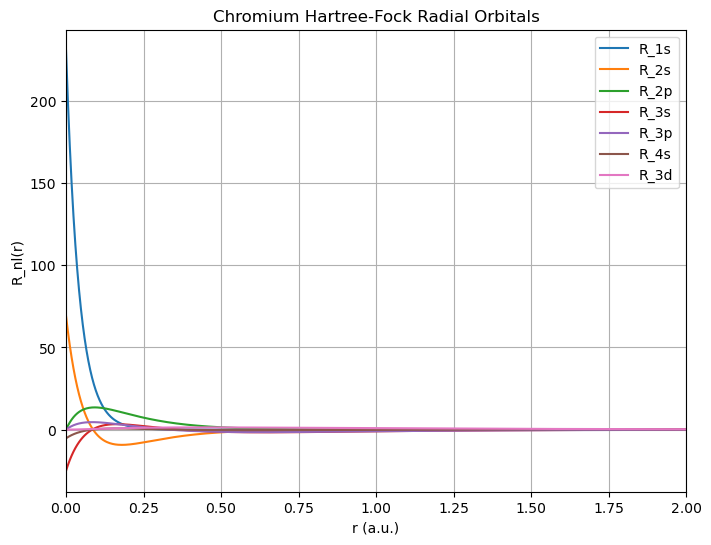

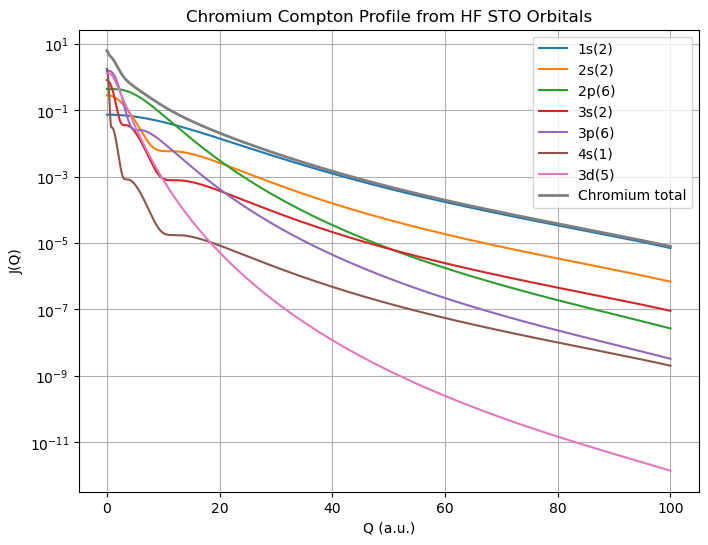

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Chromium Hartree-Fock STO data
# Cr: 1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(5) 4s(1)
# Format: (n_j, Z_j, C_j)
# =====================================================

chromium_1s = [
    (1,24.7292,  0.937075),
    (2,21.1386,  0.068919),
    (2, 9.9971,  0.000859),
    (3,30.4212,  0.009143),
    (3, 7.3629,  0.000019),
    (3, 5.1830, -0.000126),
    (3, 3.4391,  0.000025),
    (4,11.9538, -0.000067),
    (4, 2.1124, -0.000010),
    (4, 1.3241,  0.000006),
    (4, 0.8703, -0.000002),
]

chromium_2s = [
    (1,24.7292,  0.280906),
    (2,21.1386,  0.177565),
    (2, 9.9971, -1.021993),
    (3,30.4212,  0.001001),
    (3, 7.3629, -0.083861),
    (3, 5.1830,  0.007943),
    (3, 3.4391, -0.003056),
    (4,11.9538, -0.068373),
    (4, 2.1124,  0.000328),
    (4, 1.3241, -0.000305),
    (4, 0.8703,  0.000000),
]

chromium_3s = [
    (1,24.7292, -0.101688),
    (2,21.1386, -0.074243),
    (2, 9.9971,  0.436116),
    (3,30.4212, -0.001037),
    (3, 7.3629,  0.108518),
    (3, 5.1830, -0.632268),
    (3, 3.4391, -0.583503),
    (4,11.9538,  0.090243),
    (4, 2.1124, -0.011065),
    (4, 1.3241,  0.002196),
    (4, 0.8703, -0.000417),
]

chromium_4s = [
    (1,24.7292, -0.021485),
    (2,21.1386, -0.015920),
    (2, 9.9971,  0.093634),
    (3,30.4212, -0.000219),
    (3, 7.3629,  0.031754),
    (3, 5.1830, -0.170396),
    (3, 3.4391, -0.128499),
    (4,11.9538,  0.020770),
    (4, 2.1124,  0.225866),
    (4, 1.3241,  0.541426),
    (4, 0.8703,  0.358079),
]

chromium_2p = [
    (2,37.4230,  0.000786),
    (2,14.8415,  0.333715),
    (2, 7.8404,  0.420845),
    (2, 3.6199,  0.005346),
    (3,11.9471,  0.294186),
    (3, 2.9491, -0.000612),
    (3, 1.9545,  0.000251),
]

chromium_3p = [
    (2,37.4230,  0.000199),
    (2,14.8415,  0.070569),
    (2, 7.8404,  0.496567),
    (2, 3.6199, -0.823061),
    (3,11.9471,  0.014369),
    (3, 2.9491, -0.389092),
    (3, 1.9545, -0.049588),
]

chromium_3d = [
    (3,11.4813, 0.016904),
    (3, 5.8159, 0.198001),
    (3, 3.4526, 0.403137),
    (3, 1.9741, 0.392975),
    (3, 1.1473, 0.182481),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================

def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 120.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Chromium radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, chromium_1s)
R2s = R_nl(r, chromium_2s)
R3s = R_nl(r, chromium_3s)
R4s = R_nl(r, chromium_4s)
R2p = R_nl(r, chromium_2p)
R3p = R_nl(r, chromium_3p)
R3d = R_nl(r, chromium_3d)

print_R_formula(chromium_1s, "Cr_R1s")
print_R_formula(chromium_2s, "Cr_R2s")
print_R_formula(chromium_3s, "Cr_R3s")
print_R_formula(chromium_4s, "Cr_R4s")
print_R_formula(chromium_2p, "Cr_R2p")
print_R_formula(chromium_3p, "Cr_R3p")
print_R_formula(chromium_3d, "Cr_R3d")
# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_4s = chi_p(p, r, R4s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_3d = chi_p(p, r, R3d, l=2)


# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_3d, J_3d = calculate_J(p, chi_3d, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))
print("Norm 3s =", np.trapezoid(I_3s, p))
print("Norm 3p =", np.trapezoid(I_3p, p))
print("Norm 3d =", np.trapezoid(I_3d, p))
print("Norm 4s =", np.trapezoid(I_4s, p))

# Chromium has 1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(5) 4s(1)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + 5*J_3d + J_4s

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_3d_one_electron": J_3d,
    "J_4s_one_electron": J_4s,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(2)": 2*J_3s,
    "J_3p(6)": 6*J_3p,
    "J_4s(2)": 1*J_4s,
    "J_3d(5)": 5*J_3d,
    "J_total_Chromium": J_total
    })
print(table)
table.to_csv("Chromium_HF_Compton_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.plot(r, R3d, label="R_3d")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Chromium Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 6*J_3p, label="3p(6)")
plt.plot(Q, J_4s, label="4s(1)")
plt.plot(Q, 5*J_3d, label="3d(5)")
plt.plot(Q, J_total, label="Chromium total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Chromium Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()